In [ ]:
from google.colab import files
print("Select the Netflix Top 10 zip you downloaded from Kaggle")
uploaded = files.upload()  # pick the .zip file

Select the Netflix Top 10 zip you downloaded from Kaggle


Saving archive (7).zip to archive (7).zip


In [ ]:
import zipfile, os

# Grab whatever zip you just uploaded
zip_name = [f for f in uploaded.keys() if f.endswith(".zip")][0]

with zipfile.ZipFile(zip_name, "r") as z:
    z.extractall(".")

print("Files now available:")
for f in os.listdir("."):
    if f.endswith(".csv"):
        print(" -", f)

Files now available:
 - most-popular.csv
 - all-weeks-countries.csv
 - all-weeks-global.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [ ]:
g = pd.read_csv("all-weeks-global.csv")
c = pd.read_csv("all-weeks-countries.csv")

print("GLOBAL:", g.shape)
print("COUNTRIES:", c.shape)
display(g.head())
display(c.head())

GLOBAL: (2400, 7)
COUNTRIES: (112300, 8)


,week,category,weekly_rank,show_title,season_title,weekly_hours_viewed,cumulative_weeks_in_top_10
0,2022-08-21,Films (English),1,Day Shift,NaN,63390000,2
1,2022-08-21,Films (English),2,Look Both Ways,NaN,48060000,1
2,2022-08-21,Films (English),3,The Next 365 Days,NaN,39310000,1
3,2022-08-21,Films (English),4,Purple Hearts,NaN,23410000,4
4,2022-08-21,Films (English),5,Untold: The Girlfriend Who Didn't Exist,NaN,20050000,1


,country_name,country_iso2,week,category,weekly_rank,show_title,season_title,cumulative_weeks_in_top_10
0,Argentina,AR,2022-08-21,Films,1,Look Both Ways,NaN,1
1,Argentina,AR,2022-08-21,Films,2,Day Shift,NaN,2
2,Argentina,AR,2022-08-21,Films,3,Bank Robbers: The Last Great Heist,NaN,2
3,Argentina,AR,2022-08-21,Films,4,The Next 365 Days,NaN,1
4,Argentina,AR,2022-08-21,Films,5,The Angry Birds Movie 2,NaN,1


In [ ]:
for name, df in [("GLOBAL", g), ("COUNTRIES", c)]:
    print(f"\n===== {name} =====")
    print(df.dtypes)
    print("\nNulls:\n", df.isna().sum())
    print("\nDuplicates:", df.duplicated().sum())


===== GLOBAL =====
week                          object
category                      object
weekly_rank                    int64
show_title                    object
season_title                  object
weekly_hours_viewed            int64
cumulative_weeks_in_top_10     int64
dtype: object

Nulls:
 week                             0
category                         0
weekly_rank                      0
show_title                       0
season_title                  1228
weekly_hours_viewed              0
cumulative_weeks_in_top_10       0
dtype: int64

Duplicates: 0

===== COUNTRIES =====
country_name                  object
country_iso2                  object
week                          object
category                      object
weekly_rank                    int64
show_title                    object
season_title                  object
cumulative_weeks_in_top_10     int64
dtype: object

Nulls:
 country_name                      0
country_iso2                      0
week       

In [ ]:
# Parse week to datetime
g["week"] = pd.to_datetime(g["week"])
c["week"] = pd.to_datetime(c["week"])

# Films have NaN season_title; TV has it. Build one clean title column.
g["title"] = g["season_title"].fillna(g["show_title"])
c["title"] = c["season_title"].fillna(c["show_title"])

# Split "category" -> format (Films/TV) + language (English/Non-English)
g[["format", "language"]] = g["category"].str.extract(r"(Films|TV)\s*\((English|Non-English)\)")
c[["format", "language"]] = c["category"].str.extract(r"(Films|TV)\s*\((English|Non-English)\)")

# Quick check
print(g[["week","category","format","language","title","weekly_hours_viewed"]].head())
print("\nUnique categories:", g["category"].unique())

        week         category format language                                    title  weekly_hours_viewed
0 2022-08-21  Films (English)  Films  English                                Day Shift             63390000
1 2022-08-21  Films (English)  Films  English                           Look Both Ways             48060000
2 2022-08-21  Films (English)  Films  English                        The Next 365 Days             39310000
3 2022-08-21  Films (English)  Films  English                            Purple Hearts             23410000
4 2022-08-21  Films (English)  Films  English  Untold: The Girlfriend Who Didn't Exist             20050000

Unique categories: ['Films (English)' 'Films (Non-English)' 'TV (English)' 'TV (Non-English)']


In [ ]:
print("Date range (global):", g["week"].min().date(), "→", g["week"].max().date())
print("Unique titles (global):", g["title"].nunique())
print("Unique countries:", c["country_name"].nunique())
print("\nRows per category:\n", g["category"].value_counts())

Date range (global): 2021-07-04 → 2022-08-21
Unique titles (global): 873
Unique countries: 94

Rows per category:
 category
Films (English)        600
Films (Non-English)    600
TV (English)           600
TV (Non-English)       600
Name: count, dtype: int64


In [ ]:
def human(n):
    """Format large numbers: 1_500_000_000 -> '1.5B'."""
    if pd.isna(n): return "—"
    for unit in ["", "K", "M", "B", "T"]:
        if abs(n) < 1000:
            return f"{n:.1f}{unit}"
        n /= 1000
    return f"{n:.1f}P"

def thousands(x, pos):
    return human(x)

from matplotlib.ticker import FuncFormatter
fmt = FuncFormatter(thousands)

In [ ]:
total_hours = g["weekly_hours_viewed"].sum()
n_titles = g["title"].nunique()
n_weeks = g["week"].nunique()
top_title = g.groupby("title")["weekly_hours_viewed"].sum().idxmax()
top_title_hours = g.groupby("title")["weekly_hours_viewed"].sum().max()

print("="*45)
print("  NETFLIX GLOBAL TOP 10 — KEY METRICS")
print("="*45)
print(f"  Total hours viewed (all-time) : {human(total_hours)}")
print(f"  Unique titles tracked         : {n_titles}")
print(f"  Weeks covered                 : {n_weeks}")
print(f"  Biggest title                 : {top_title}")
print(f"  ...with total hours           : {human(top_title_hours)}")
print("="*45)

  NETFLIX GLOBAL TOP 10 — KEY METRICS
  Total hours viewed (all-time) : 47.8B
  Unique titles tracked         : 873
  Weeks covered                 : 60
  Biggest title                 : Squid Game: Season 1
  ...with total hours           : 2.3B


In [ ]:
# Top 15 titles by cumulative hours
top_titles = (g.groupby("title")["weekly_hours_viewed"]
                .sum().sort_values(ascending=False).head(15))

# Hours by category
cat_hours = g.groupby("category")["weekly_hours_viewed"].sum().sort_values()

# Hours by language
lang_hours = g.groupby("language")["weekly_hours_viewed"].sum()

# Hours by format
fmt_hours = g.groupby("format")["weekly_hours_viewed"].sum()

# Weekly total hours over time (trend)
weekly_trend = g.groupby("week")["weekly_hours_viewed"].sum()

# Staying power: max weeks in top 10 per format
shelf = g.groupby("format")["cumulative_weeks_in_top_10"].agg(["mean","max"])

# Longest-running titles
longest = (g.groupby("title")["cumulative_weeks_in_top_10"]
             .max().sort_values(ascending=False).head(15))

display(top_titles)
display(shelf)

,weekly_hours_viewed
title,
Squid Game: Season 1,2289500000
Stranger Things 4,1793590000
Money Heist: Part 5,905230000
Café con aroma de mujer: Season 1,793740000
Bridgerton: Season 2,775240000
All of Us Are Dead: Season 1,659510000
Maid: Limited Series,655510000
Inventing Anna: Limited Series,654560000
Ozark: Season 4,581930000


,mean,max
format,,
Films,2.322500,14
TV,4.015833,30


In [ ]:
# Use the biggest title automatically, or set manually
hit = top_title
decay = (g[g["title"] == hit]
         .sort_values("week")[["week","weekly_hours_viewed","cumulative_weeks_in_top_10"]])
print("Tracking decay for:", hit)
display(decay)

Tracking decay for: Squid Game: Season 1


,week,weekly_hours_viewed,cumulative_weeks_in_top_10
1950,2021-09-19,63190000,1
1910,2021-09-26,448730000,2
1870,2021-10-03,571760000,3
1830,2021-10-10,412940000,4
1790,2021-10-17,258840000,5
1750,2021-10-24,147560000,6
1710,2021-10-31,90100000,7
1670,2021-11-07,65000000,8
1630,2021-11-14,42790000,9
1592,2021-11-21,30410000,10


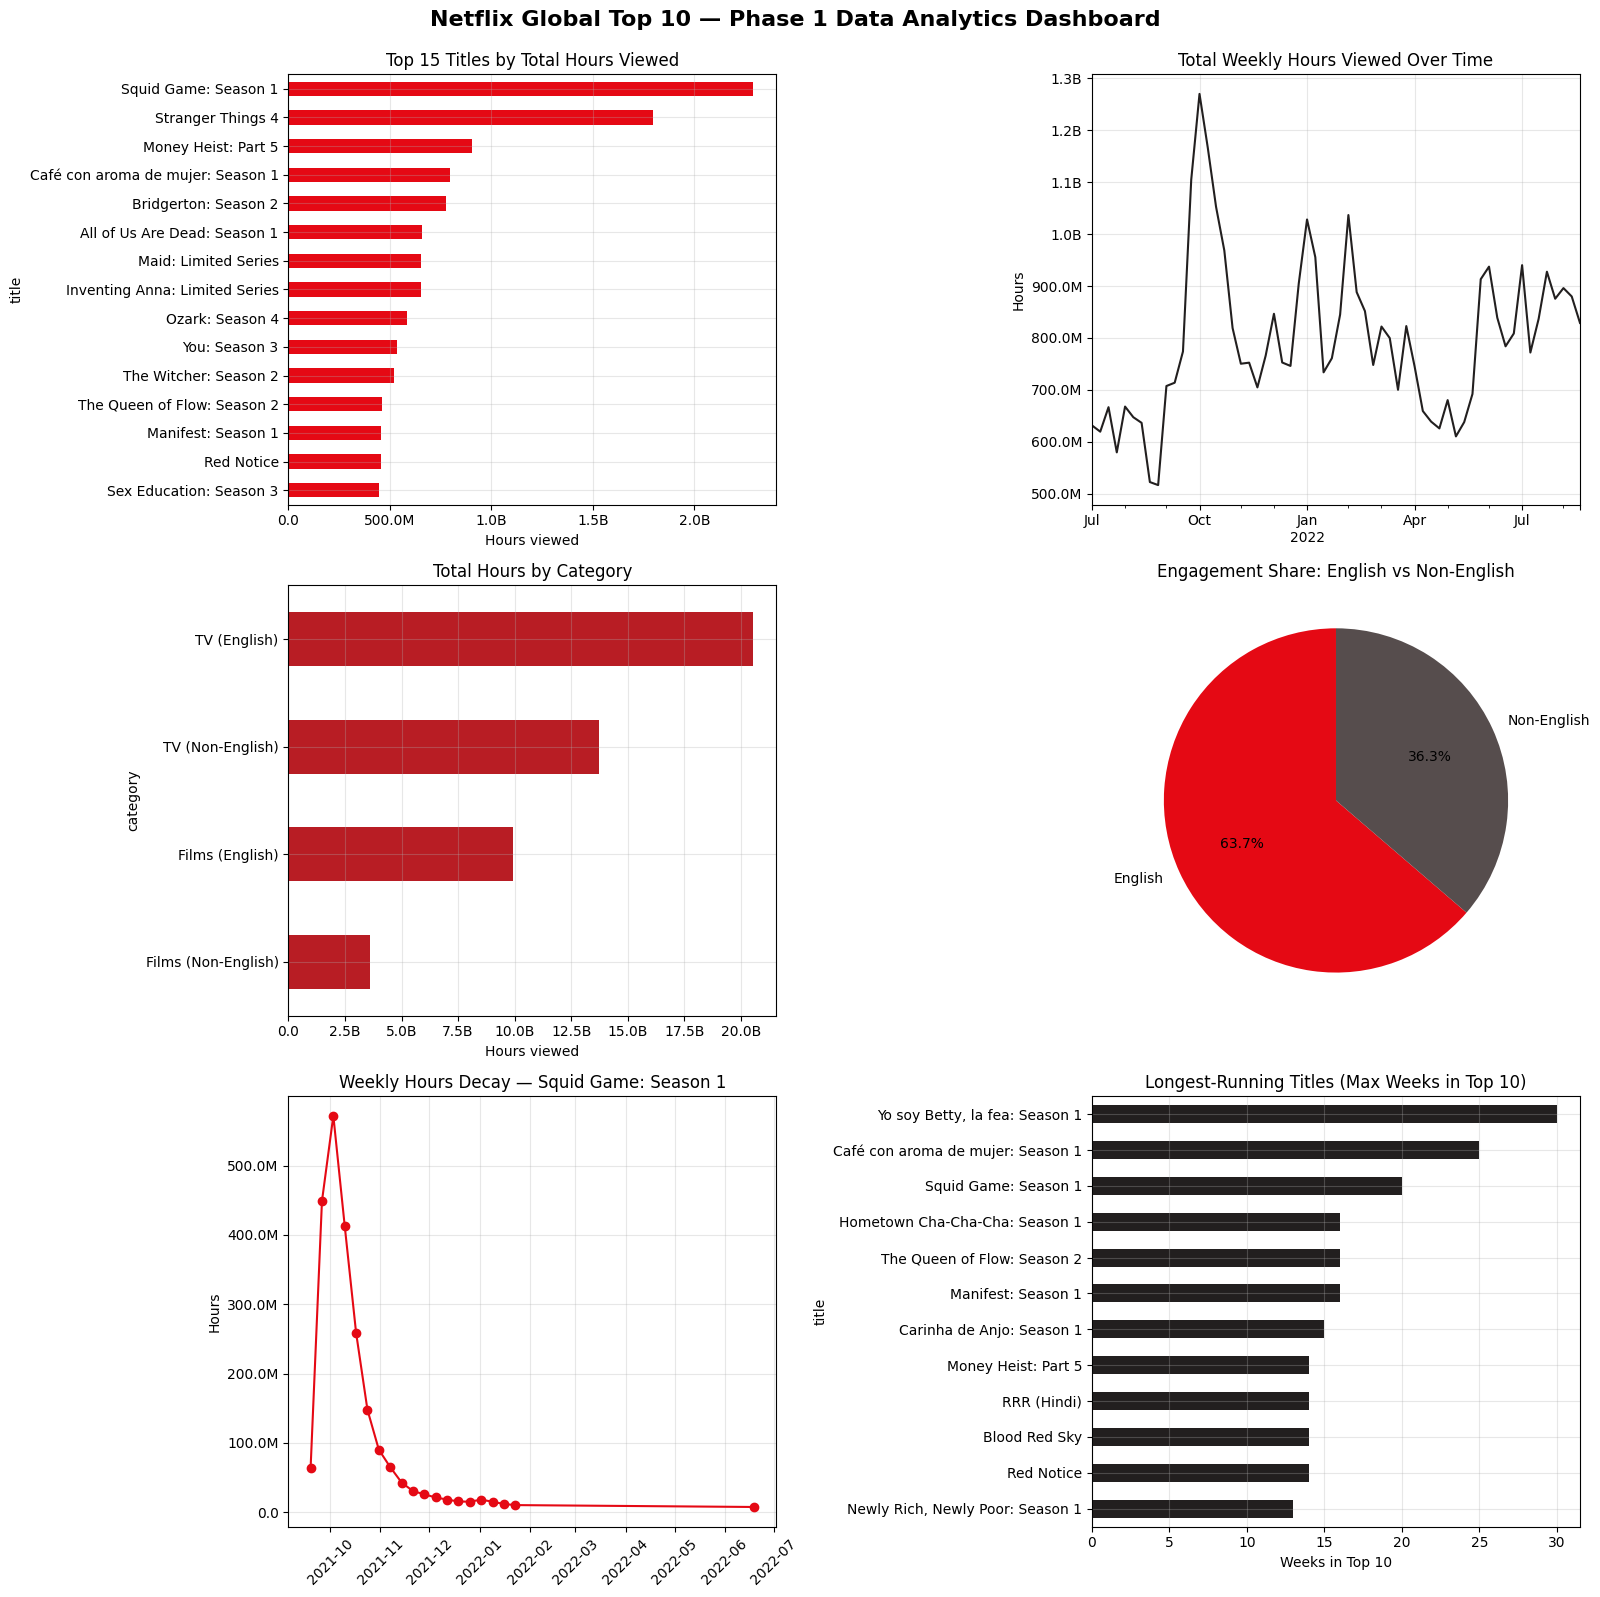

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(16, 16))
fig.suptitle("Netflix Global Top 10 — Phase 1 Data Analytics Dashboard",
             fontsize=16, fontweight="bold", y=0.995)

# (1) Top 15 titles by total hours
ax = axes[0, 0]
top_titles.sort_values().plot(kind="barh", ax=ax, color="#E50914")
ax.set_title("Top 15 Titles by Total Hours Viewed")
ax.set_xlabel("Hours viewed")
ax.xaxis.set_major_formatter(fmt)

# (2) Weekly total hours trend
ax = axes[0, 1]
weekly_trend.plot(ax=ax, color="#221F1F")
ax.set_title("Total Weekly Hours Viewed Over Time")
ax.set_xlabel(""); ax.set_ylabel("Hours")
ax.yaxis.set_major_formatter(fmt)

# (3) Hours by category
ax = axes[1, 0]
cat_hours.plot(kind="barh", ax=ax, color="#B81D24")
ax.set_title("Total Hours by Category")
ax.set_xlabel("Hours viewed")
ax.xaxis.set_major_formatter(fmt)

# (4) Language split (pie)
ax = axes[1, 1]
ax.pie(lang_hours, labels=lang_hours.index, autopct="%1.1f%%",
       colors=["#E50914", "#564D4D"], startangle=90)
ax.set_title("Engagement Share: English vs Non-English")

# (5) Decay curve of the biggest hit
ax = axes[2, 0]
ax.plot(decay["week"], decay["weekly_hours_viewed"], marker="o", color="#E50914")
ax.set_title(f"Weekly Hours Decay — {hit}")
ax.set_xlabel(""); ax.set_ylabel("Hours")
ax.yaxis.set_major_formatter(fmt)
ax.tick_params(axis="x", rotation=45)

# (6) Staying power: longest-running titles
ax = axes[2, 1]
longest.head(12).sort_values().plot(kind="barh", ax=ax, color="#221F1F")
ax.set_title("Longest-Running Titles (Max Weeks in Top 10)")
ax.set_xlabel("Weeks in Top 10")

plt.tight_layout()
plt.show()

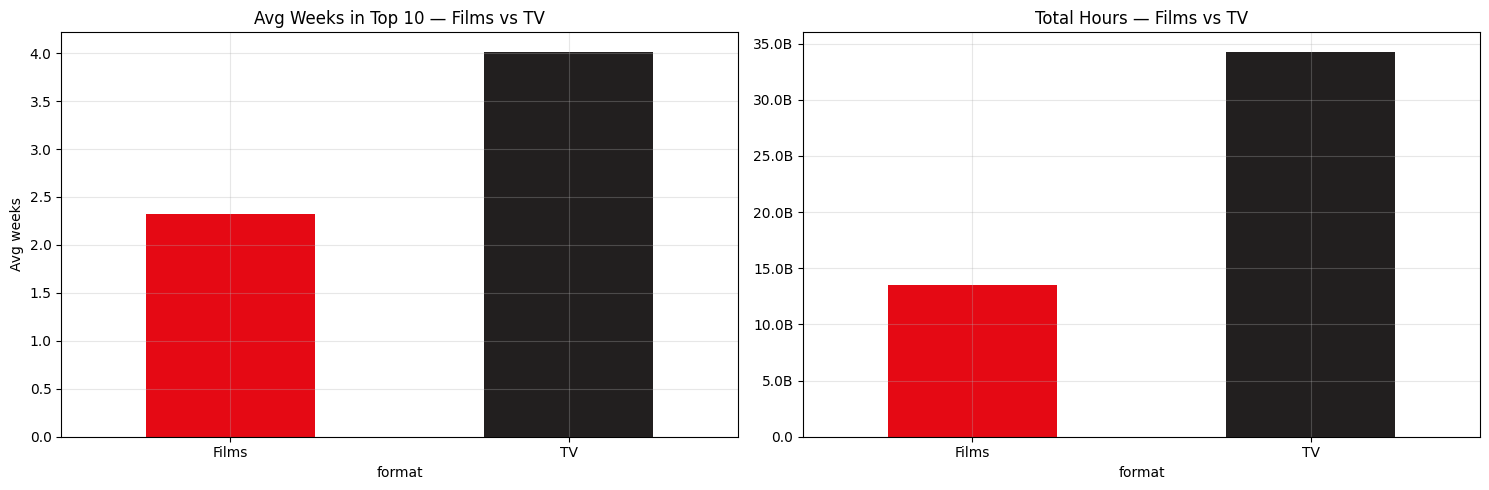

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

shelf["mean"].plot(kind="bar", ax=axes[0], color=["#E50914","#221F1F"])
axes[0].set_title("Avg Weeks in Top 10 — Films vs TV")
axes[0].set_ylabel("Avg weeks"); axes[0].tick_params(axis="x", rotation=0)

fmt_hours.plot(kind="bar", ax=axes[1], color=["#E50914","#221F1F"])
axes[1].set_title("Total Hours — Films vs TV")
axes[1].yaxis.set_major_formatter(fmt); axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
# Most frequent #1 title per country (uses weekly_rank == 1)
top_per_country = (c[c["weekly_rank"] == 1]
                   .groupby("country_name")["title"]
                   .agg(lambda s: s.value_counts().idxmax()))
print("Most frequent #1 title by country (sample):")
display(top_per_country.head(20))

# Countries tracked
print("\nTotal countries:", c["country_name"].nunique())

Most frequent #1 title by country (sample):


,title
country_name,
Argentina,Café con aroma de mujer: Season 1
Australia,Stranger Things 4
Austria,Squid Game: Season 1
Bahamas,Stranger Things 4
Bahrain,Squid Game: Season 1
Bangladesh,Squid Game: Season 1
Belgium,Stranger Things 4
Bolivia,"Yo soy Betty, la fea: Season 1"
Brazil,Carrossel



Total countries: 94


In [ ]:
g.to_csv("netflix_global_clean.csv", index=False)
c.to_csv("netflix_countries_clean.csv", index=False)
from google.colab import files
files.download("netflix_global_clean.csv")
files.download("netflix_countries_clean.csv")
print("Saved cleaned files — we'll load these in Phase 2.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved cleaned files — we'll load these in Phase 2.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

g = pd.read_csv("netflix_global_clean.csv", parse_dates=["week"])
c = pd.read_csv("netflix_countries_clean.csv", parse_dates=["week"])

def human(n):
    if pd.isna(n): return "—"
    for u in ["", "K", "M", "B", "T"]:
        if abs(n) < 1000: return f"{n:.1f}{u}"
        n /= 1000
    return f"{n:.1f}P"
fmt = FuncFormatter(lambda x, pos: human(x))

print("Global:", g.shape, "| Countries:", c.shape)

Global: (2400, 10) | Countries: (112300, 11)


In [ ]:
# Country category is just "Films"/"TV" — copy it to format
c["format"] = c["category"]
# Language genuinely isn't in the country file; drop the empty column to avoid confusion
c = c.drop(columns=["language"])
print("Country formats:", c["format"].unique())
print("Country file has hours column:", "weekly_hours_viewed" in c.columns)

Country formats: ['Films' 'TV']
Country file has hours column: False


In [ ]:
eng_hours = g.groupby("language")["weekly_hours_viewed"].sum()
eng_titles = g.groupby("language")["title"].nunique()
ba1 = pd.DataFrame({
    "hours_viewed": eng_hours,
    "pct_of_hours": (eng_hours/eng_hours.sum()*100).round(1),
    "distinct_titles": eng_titles,
    "pct_of_titles": (eng_titles/eng_titles.sum()*100).round(1),
})
ba1["engagement_index"] = (ba1["pct_of_hours"]/ba1["pct_of_titles"]).round(2)
print("Index > 1 = drives more viewing than its share of titles\n")
display(ba1)

Index > 1 = drives more viewing than its share of titles



,hours_viewed,pct_of_hours,distinct_titles,pct_of_titles,engagement_index
language,,,,,
English,30455340000,63.7,471,53.9,1.18
Non-English,17356090000,36.3,403,46.1,0.79


In [ ]:
# Since language isn't available per-country, profile by Films vs TV preference
c["is_tv"] = c["format"].eq("TV")
country_format = (c[c["weekly_rank"] == 1]
                  .groupby("country_name")["is_tv"]
                  .mean().mul(100).round(1)
                  .sort_values(ascending=False))
print("Top 15 most TV-leaning markets (% of #1 hits that are TV):")
display(country_format.head(15))
print("\nMost film-leaning markets:")
display(country_format.tail(15))

Top 15 most TV-leaning markets (% of #1 hits that are TV):


,is_tv
country_name,
Argentina,50.0
Australia,50.0
Austria,50.0
Bahamas,50.0
Bahrain,50.0
Bangladesh,50.0
Belgium,50.0
Bolivia,50.0
Brazil,50.0



Most film-leaning markets:


,is_tv
country_name,
Spain,50.0
Sri Lanka,50.0
Sweden,50.0
Switzerland,50.0
Taiwan,50.0
Thailand,50.0
Trinidad and Tobago,50.0
Turkey,50.0
Ukraine,50.0


In [ ]:
# Smart workaround: map each title's language from the global file, then apply to countries
title_language = g.drop_duplicates("title").set_index("title")["language"]
c["language"] = c["title"].map(title_language)

coverage = c["language"].notna().mean()*100
print(f"Recovered language for {coverage:.1f}% of country rows via global mapping\n")

c["is_non_english"] = c["language"].eq("Non-English")
country_taste = (c[(c["weekly_rank"]==1) & c["language"].notna()]
                 .groupby("country_name")["is_non_english"]
                 .mean().mul(100).round(1)
                 .sort_values(ascending=False))
print("Top 15 countries by % of #1 hits that are Non-English:")
display(country_taste.head(15))

Recovered language for 77.0% of country rows via global mapping

Top 15 countries by % of #1 hits that are Non-English:


,is_non_english
country_name,
South Korea,82.7
Japan,79.4
India,69.2
Bangladesh,64.5
Taiwan,63.2
Thailand,62.9
Indonesia,58.8
Vietnam,57.3
Turkey,52.5


,avg_weeks,max_weeks,total_hours,avg_hours_per_appearance
format,,,,
Films,2.3,14,13527420000,11272850.0
TV,4.0,30,34284010000,28570008.3


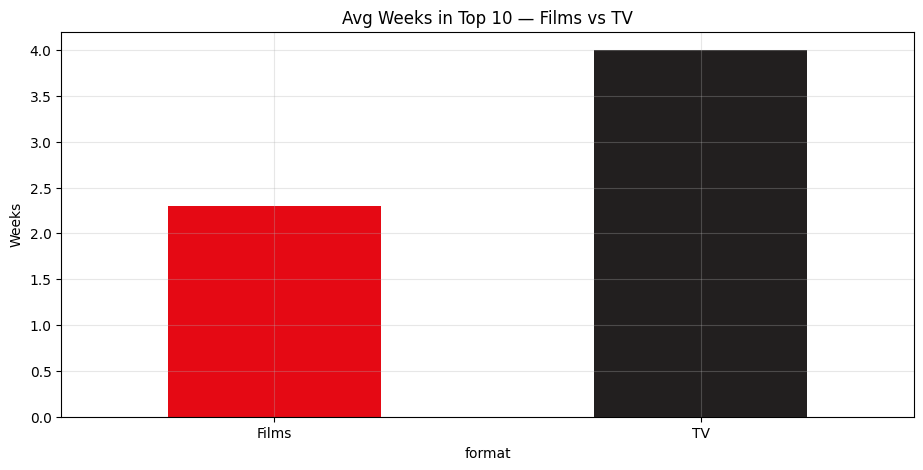

In [ ]:
staying = g.groupby("format").agg(
    avg_weeks=("cumulative_weeks_in_top_10","mean"),
    max_weeks=("cumulative_weeks_in_top_10","max"),
    total_hours=("weekly_hours_viewed","sum"),
    avg_hours_per_appearance=("weekly_hours_viewed","mean"),
).round(1)
display(staying)
staying["avg_weeks"].plot(kind="bar", color=["#E50914","#221F1F"], rot=0,
                          title="Avg Weeks in Top 10 — Films vs TV")
plt.ylabel("Weeks"); plt.show()

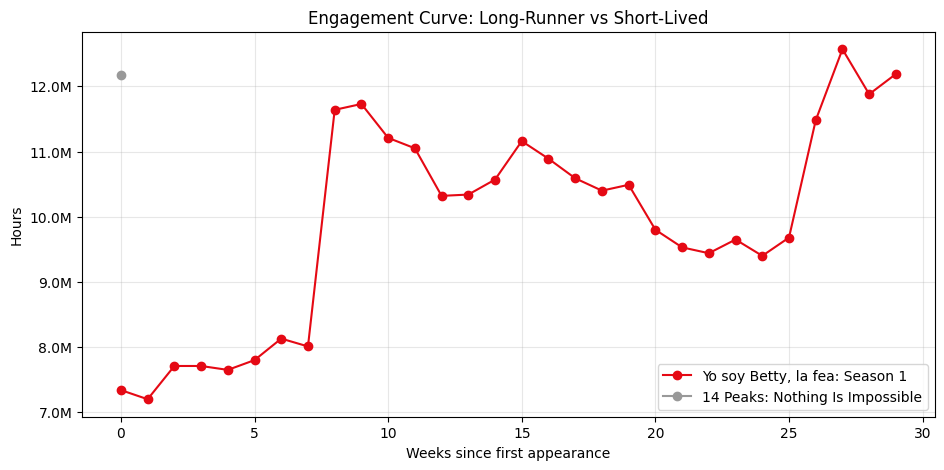

In [ ]:
weeks_by_title = g.groupby("title")["cumulative_weeks_in_top_10"].max().sort_values(ascending=False)
long_runner = weeks_by_title.index[0]
one_weekers = weeks_by_title[weeks_by_title==1].index
flop = one_weekers[0] if len(one_weekers) else weeks_by_title.index[-1]

fig, ax = plt.subplots(figsize=(11,5))
for t, col in [(long_runner,"#E50914"), (flop,"#999999")]:
    s = g[g["title"]==t].sort_values("week")
    ax.plot(range(len(s)), s["weekly_hours_viewed"], marker="o", label=t, color=col)
ax.set_title("Engagement Curve: Long-Runner vs Short-Lived")
ax.set_xlabel("Weeks since first appearance"); ax.set_ylabel("Hours")
ax.yaxis.set_major_formatter(fmt); ax.legend(); plt.show()

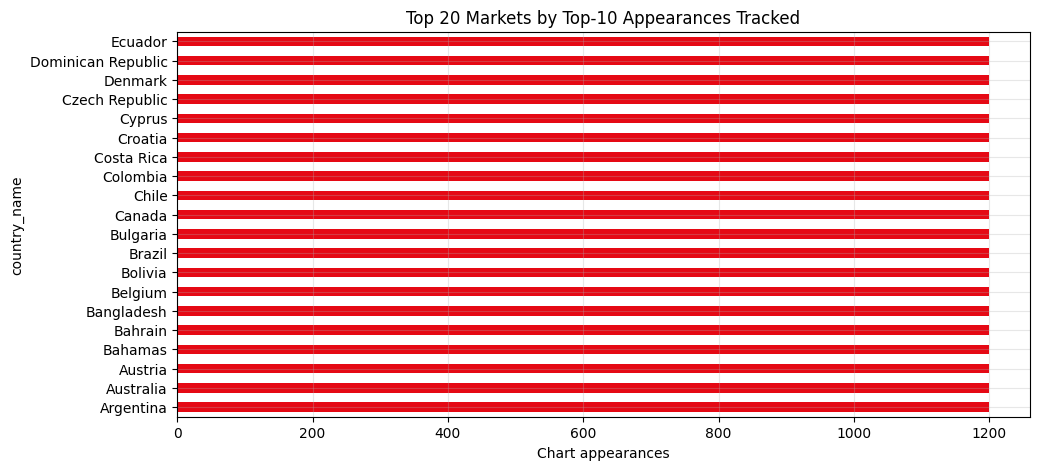

In [ ]:
market_activity = (c.groupby("country_name")["weekly_rank"]
                   .count().sort_values(ascending=False).head(20))
market_activity.sort_values().plot(kind="barh", color="#E50914",
                                   title="Top 20 Markets by Top-10 Appearances Tracked")
plt.xlabel("Chart appearances"); plt.show()

In [ ]:
summary = {
    "Total hours viewed (global)": human(g["weekly_hours_viewed"].sum()),
    "Distinct titles tracked": g["title"].nunique(),
    "Non-English engagement index": ba1.loc["Non-English","engagement_index"] if "Non-English" in ba1.index else "n/a",
    "Avg weeks on list (Films)": staying.loc["Films","avg_weeks"] if "Films" in staying.index else "n/a",
    "Avg weeks on list (TV)": staying.loc["TV","avg_weeks"] if "TV" in staying.index else "n/a",
    "Longest-running title": long_runner,
    "Countries tracked": c["country_name"].nunique(),
}
print("="*50)
print("  NETFLIX TOP 10 — BUSINESS ANALYTICS SUMMARY")
print("="*50)
for k,v in summary.items():
    print(f"  {k:<32}: {v}")
print("="*50)

  NETFLIX TOP 10 — BUSINESS ANALYTICS SUMMARY
  Total hours viewed (global)     : 47.8B
  Distinct titles tracked         : 873
  Non-English engagement index    : 0.79
  Avg weeks on list (Films)       : 2.3
  Avg weeks on list (TV)          : 4.0
  Longest-running title           : Yo soy Betty, la fea: Season 1
  Countries tracked               : 94
